In [1]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Pakistan\Desktop\Stock_Price_Prediction
['.ipynb_checkpoints', 'Stock_analysis.ipynb', 'stock_dataset_500_rows.csv']


Import Libraries

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score

Load Dataset

In [4]:
df = pd.read_csv("stock_dataset_500_rows.csv")
print("Dataset Shape:")
print(df.shape)
df.head()

Dataset Shape:
(500, 5)


,Opening Price,Closing Price,High,Low,Trading Volume
0,98.99,96.10,99.72,95.00,2508505
1,101.73,105.31,106.02,99.85,4959107
2,104.65,104.75,107.69,101.40,2770889
3,105.69,106.35,108.67,105.15,1633264
4,106.08,105.87,108.34,104.62,724203


Data Preprocessing

In [5]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
df=df.dropna()
print("\nNew Shape: ")
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Opening Price   500 non-null    float64
 1   Closing Price   500 non-null    float64
 2   High            500 non-null    float64
 3   Low             500 non-null    float64
 4   Trading Volume  500 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 19.7 KB
None

Missing Values:
Opening Price     0
Closing Price     0
High              0
Low               0
Trading Volume    0
dtype: int64

New Shape: 
(500, 5)


Features and Target

In [6]:
X = df[["Opening Price", "High", "Low", "Trading Volume"]]
Y=df["Closing Price"]
print(X.head())

   Opening Price    High     Low  Trading Volume
0          98.99   99.72   95.00         2508505
1         101.73  106.02   99.85         4959107
2         104.65  107.69  101.40         2770889
3         105.69  108.67  105.15         1633264
4         106.08  108.34  104.62          724203


Train Test Split 

In [8]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.20, random_state=42)
print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 400
Testing Rows: 100


Linear Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train,Y_train)
print("Model Trained Successfully")

Model Trained Successfully


Prediction

In [10]:
Y_pred=model.predict(X_test)
print(Y_pred[:10])

[286.11763176 144.4101824  287.7801979  170.48708319 142.02259119
 301.38717891 290.50723307 156.93749227 139.89931289 336.48210476]


Accuracy Evalution

In [12]:
mae=mean_absolute_error(Y_test,Y_pred)
mse=mean_squared_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_test,Y_pred)
print("MAE=",mae)
print("MSE=",mse)
print("RMSE=",rmse)
print("R2 Score=", r2)


MAE= 1.3011004357177989
MSE= 2.3990828221715823
RMSE= 1.5488972923249567
R2 Score= 0.9996358507542453


Actual vs Predicted

In [12]:
comparison=pd.DataFrame({
    'Actual':Y_test.values,
    'Predicted':Y_pred})
comparison.head(20)

,Actual,Predicted
0,288.18,286.117632
1,145.33,144.410182
2,289.53,287.780198
3,169.45,170.487083
4,142.16,142.022591
5,300.22,301.387179
6,292.97,290.507233
7,154.82,156.937492
8,136.54,139.899313
9,333.61,336.482105


Visualization

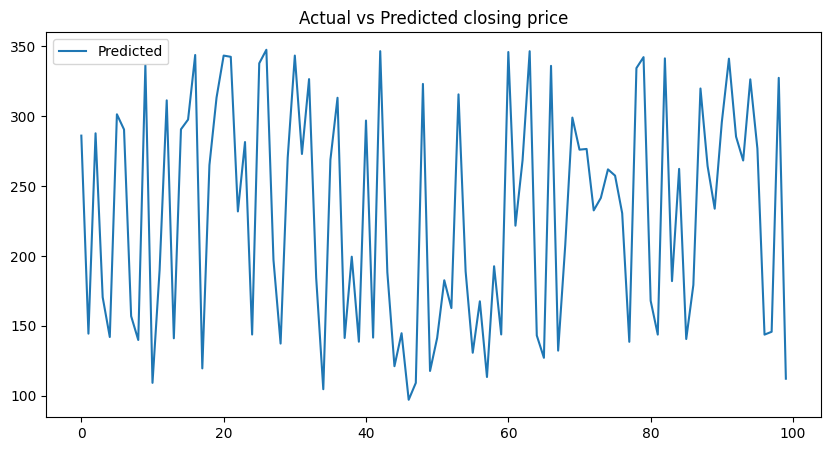

In [13]:
plt.figure(figsize=(10,5))
plt.plot(Y_pred,label='Predicted')
plt.legend()
plt.title("Actual vs Predicted closing price")
plt.show()

Future Stock Price Prediction

In [ ]:
Opening_Price = float(input("Opening_Price:"))
High=float(input("High Price:"))
Low= float(input("Low Price:"))
Trading_Volume=3000000
future_data=[[
    Opening_Price,
    High,
    Low,
    Trading_Volume]]
prediction=model.predict(future_data)
print("\nPredicted Closing Price=",round(prediction[0],2))
